In [13]:
# Data Collection
import nltk
nltk.download('gutenberg')
from nltk.corpus import gutenberg
import pandas as pd


[nltk_data] Downloading package gutenberg to
[nltk_data]     C:\Users\murat\AppData\Roaming\nltk_data...
[nltk_data]   Package gutenberg is already up-to-date!


```htm

Amaç: nltk kütüphanesinden Shakespeare'in "Hamlet" metnini almak.
gutenberg Kütüphanesi: İçerisinde çeşitli klasik metinler bulunan bir veri kaynağıdır.
nltk.download('gutenberg'): Gerekli veri setini indirir.

```

In [14]:
# Load the dataset
data = gutenberg.raw('shakespeare-hamlet.txt')
# save to a text file
with open('hamlet.txt', 'w', encoding='utf-8') as f:
    f.write(data)



```css
Amaç: "Hamlet" metnini gutenberg'den alıp bir değişkene (data) yüklemek.
Kaydetme: Metni bir .txt dosyasına (hamlet.txt) kaydediyoruz. Bu, metni daha sonra kolayca işlemek için kullanılır.
```

In [15]:
# Data preprocessing

import numpy as np
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split

# Load the dataset
with open('hamlet.txt', 'r', encoding='utf-8') as f:
    text = f.read().lower()

# Tokenization
tokenizer = Tokenizer()
tokenizer.fit_on_texts([text])

total_words = len(tokenizer.word_index) + 1
total_words




4818

```css
Amaç: Metni modelin anlayabileceği bir formata dönüştürmek.
Adımlar:
Metni Küçük Harfe Çevirme: Tüm metni küçük harfe çevirerek tutarlılık sağlanır.
Tokenization: Tokenizer kullanılarak kelimeler sayısal değerlere dönüştürülür.
Kelime Sayısı (total_words): Tokenizer tarafından oluşturulan kelime sayısını hesaplar.
```

In [16]:
# create input sequences
input_sequences = []
for line in text.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_sequence = token_list[:i + 1]
        input_sequences.append(n_gram_sequence)

input_sequences

[[1, 687],
 [1, 687, 4],
 [1, 687, 4, 45],
 [1, 687, 4, 45, 41],
 [1, 687, 4, 45, 41, 1886],
 [1, 687, 4, 45, 41, 1886, 1887],
 [1, 687, 4, 45, 41, 1886, 1887, 1888],
 [1180, 1889],
 [1180, 1889, 1890],
 [1180, 1889, 1890, 1891],
 [57, 407],
 [57, 407, 2],
 [57, 407, 2, 1181],
 [57, 407, 2, 1181, 177],
 [57, 407, 2, 1181, 177, 1892],
 [407, 1182],
 [407, 1182, 63],
 [408, 162],
 [408, 162, 377],
 [408, 162, 377, 21],
 [408, 162, 377, 21, 247],
 [408, 162, 377, 21, 247, 882],
 [18, 66],
 [451, 224],
 [451, 224, 248],
 [451, 224, 248, 1],
 [451, 224, 248, 1, 30],
 [408, 407],
 [451, 25],
 [408, 6],
 [408, 6, 43],
 [408, 6, 43, 62],
 [408, 6, 43, 62, 1893],
 [408, 6, 43, 62, 1893, 96],
 [408, 6, 43, 62, 1893, 96, 18],
 [408, 6, 43, 62, 1893, 96, 18, 566],
 [451, 71],
 [451, 71, 51],
 [451, 71, 51, 1894],
 [451, 71, 51, 1894, 567],
 [451, 71, 51, 1894, 567, 378],
 [451, 71, 51, 1894, 567, 378, 80],
 [451, 71, 51, 1894, 567, 378, 80, 3],
 [451, 71, 51, 1894, 567, 378, 80, 3, 273],
 [451, 71

```css
Amaç: Modelin eğitimi için giriş dizileri oluşturmak.
Adımlar:
Metni satırlara böler.
Her satırı tokenize eder (kelimeleri sayılara çevirir).
N-gram dizileri oluşturur (örneğin, "to be or" → [1, 2, 3]).
```

In [17]:
# Pad sequences
max_sequence_length = max([len(x) for x in input_sequences])
input_sequences = np.array(pad_sequences(input_sequences, maxlen=max_sequence_length, padding='pre'))
input_sequences

array([[   0,    0,    0, ...,    0,    1,  687],
       [   0,    0,    0, ...,    1,  687,    4],
       [   0,    0,    0, ...,  687,    4,   45],
       ...,
       [   0,    0,    0, ...,    4,   45, 1047],
       [   0,    0,    0, ...,   45, 1047,    4],
       [   0,    0,    0, ..., 1047,    4,  193]], dtype=int32)

```css
Amaç: Tüm dizileri aynı uzunluğa getirmek.
pad_sequences: Kısa dizilerin başına sıfır ekleyerek (padding='pre') tüm dizileri aynı uzunluğa getirir.
```


In [18]:
# Create predictors and label
import tensorflow as tf

x, y = input_sequences[:, :-1], input_sequences[:, -1]
y = tf.keras.utils.to_categorical(y, num_classes=total_words)

```css
Amaç: Modelin giriş (x) ve çıkış (y) verilerini ayırmak.
Adımlar:
x: Her dizinin son kelimesi hariç tüm kelimeler.
y: Her dizinin son kelimesi (tahmin edilmesi gereken kelime).
to_categorical: Çıkış verisini one-hot encoding formatına çevirir.
```

In [19]:
#Split the data into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
# Define early stopping callback
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

```css
Amaç: Veriyi eğitim ve test setine ayırmak.
train_test_split: Verinin %80'i eğitim, %20'si test için kullanılır.
```

In [20]:
# Train LSTM RNN model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input,Embedding, LSTM, Dense, Dropout

print(f"Total words: {total_words}")
print(f"Max sequence length: {max_sequence_length}")
print(input_sequences)
print(f"x_train shape: {x_train.shape}")
print(f"y_train shape: {y_train.shape}")
# Define the model
model = Sequential()
model.add(Input(shape=(x_train.shape[1],)))
model.add(Embedding(input_dim=total_words, output_dim=100, input_length=x_train.shape[1]))
model.add(LSTM(150))
model.add(Dropout(0.3))
model.add(Dense(total_words, activation='softmax'))

# Compile the model
#model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
from tensorflow.keras.optimizers import Adam

model.compile(loss='categorical_crossentropy', optimizer=Adam(learning_rate=0.0005), metrics=['accuracy'])

model.summary()

Total words: 4818
Max sequence length: 14
[[   0    0    0 ...    0    1  687]
 [   0    0    0 ...    1  687    4]
 [   0    0    0 ...  687    4   45]
 ...
 [   0    0    0 ...    4   45 1047]
 [   0    0    0 ...   45 1047    4]
 [   0    0    0 ... 1047    4  193]]
x_train shape: (20585, 13)
y_train shape: (20585, 4818)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 13, 100)        │       481,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 150)            │       150,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 150)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4818)           │       727,518 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,359,918 (5.19 MB)

 Trainable params: 1,359,918 (5.19 MB)

 Non-trainable params: 0 (0.00 B)

```css
Amaç: LSTM tabanlı bir model oluşturmak.
Katmanlar:
Input: Giriş boyutunu belirtir.
Embedding: Kelimeleri vektörlere dönüştürür.
LSTM: Sıralı veriyi işler.
Dropout: Overfitting'i önlemek için bazı nöronları rastgele devre dışı bırakır.
Dense: Çıkış katmanı, tahmin edilen kelimeyi verir.

Amaç: Modeli eğitime hazırlamak.
categorical_crossentropy: Çok sınıflı sınıflandırma için kullanılan kayıp fonksiyonu.
Adam: Optimizasyon algoritması.
```

In [21]:
# Train the model
history = model.fit(x_train, y_train, epochs=50, batch_size=64, validation_data=(x_test, y_test),verbose=1)
# Save the model
model.save('hamlet_lstm_model.keras')


Epoch 1/50
322/322 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.0290 - loss: 7.3380 - val_accuracy: 0.0336 - val_loss: 6.6266
Epoch 2/50
322/322 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.0337 - loss: 6.4836 - val_accuracy: 0.0336 - val_loss: 6.6577
Epoch 3/50
322/322 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - accuracy: 0.0383 - loss: 6.4180 - val_accuracy: 0.0412 - val_loss: 6.7014
Epoch 4/50
322/322 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - accuracy: 0.0403 - loss: 6.3718 - val_accuracy: 0.0424 - val_loss: 6.7601
Epoch 5/50
322/322 ━━━━━━━━━━━━━━━━━━━━ 15s 46ms/step - accuracy: 0.0435 - loss: 6.3194 - val_accuracy: 0.0486 - val_loss: 6.7833
Epoch 6/50
322/322 ━━━━━━━━━━━━━━━━━━━━ 13s 41ms/step - accuracy: 0.0516 - loss: 6.2150 - val_accuracy: 0.0488 - val_loss: 6.7963
Epoch 7/50
322/322 ━━━━━━━━━━━━━━━━━━━━ 12s 36ms/step - accuracy: 0.0543 - loss: 6.1506 - val_accuracy: 0.0507 - val_loss: 6.8253
Epoch 8/50
322/322 ━━━━━━━━━━━━━━━━━━━━ 13s 39ms/step - accuracy: 0.0537 - loss: 6.0794 - val

```css
Amaç: Modeli eğitim verisiyle eğitmek.
Parametreler:
epochs=50: Model 50 kez tüm veri üzerinde eğitilir.
batch_size=64: Her adımda 64 örnek kullanılır.
validation_data: Test verisiyle doğrulama yapılır.
```

Sonuçların Analizi
1. Eğitim Doğruluğu (accuracy):
Eğitim doğruluğu 50. epoch sonunda %35.7'ye ulaşmış.
Bu, modelin eğitim verisine iyi uyum sağladığını gösteriyor.
2. Doğrulama Doğruluğu (val_accuracy):
Doğrulama doğruluğu 50. epoch sonunda %6.7'ye ulaşmış.
Önceki sonuçlara göre (%5-6) küçük bir iyileşme var, ancak hâlâ düşük.
3. Eğitim ve Doğrulama Kaybı (loss ve val_loss):
Eğitim kaybı sürekli azalmış ve 50. epoch sonunda 3.18'e düşmüş.
Doğrulama kaybı ise yüksek seviyelerde kalmış (8.68). Bu, modelin doğrulama verisinde genelleme yapamadığını gösteriyor.

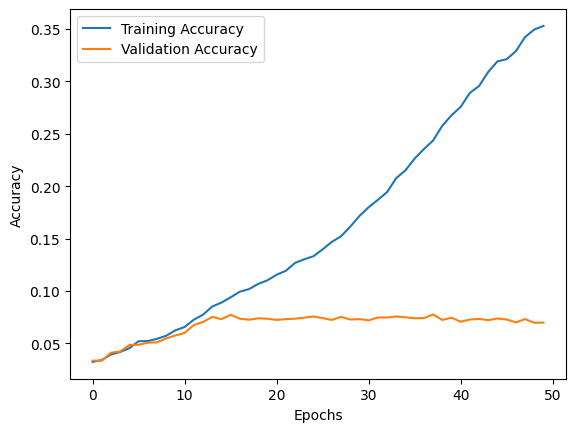

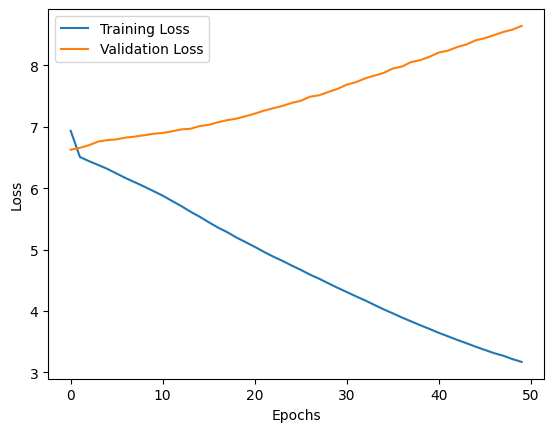

In [22]:
import matplotlib.pyplot as plt

# Eğitim ve doğrulama doğruluğu
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Eğitim ve doğrulama kaybı
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [23]:
# Function predict next word
def predict_next_word(model, tokenizer, text, max_sequence_length):
    # Tokenize the input text
    token_list = tokenizer.texts_to_sequences([text])[0]
    token_list = pad_sequences([token_list], maxlen=max_sequence_length - 1, padding='pre')
    
    # Predict the next word
    predicted = model.predict(token_list, verbose=0)
    predicted_word_index = np.argmax(predicted, axis=-1)[0]
    
    # Convert index to word
    for word, index in tokenizer.word_index.items():
        if index == predicted_word_index:
            return word
    return None

In [24]:
input_text = "Bar. Long liue the"
print(f"Input text: '{input_text}'")
predicted_word = predict_next_word(model, tokenizer, input_text, max_sequence_length)
print(f"Predicted next word: '{predicted_word}'")

# Save the tokenizer
import pickle
with open('tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f, protocol=pickle.HIGHEST_PROTOCOL)

Input text: 'Bar. Long liue the'
Predicted next word: 'king'
